In [ ]:
#!pip install jaxtyping numpy matplotlib optax pandas tensorflow-probability 

In [ ]:
#!pip install -e "C:\path to\CoinEM-main"

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
from jaxtyping import Array, Float, PyTree
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
from coinem.zoo import svgd, m_svgd_em, pgd, soul,mpgd
import optax as ox
from coinem.dataset import Dataset
from coinem.model import AbstractModel
import os
import pandas as pd
import time
from datetime import datetime
from jax.flatten_util import ravel_pytree
import glob
import tensorflow_probability.substrates.jax.distributions as tfd
import time

In [2]:
# save_dir = "figures_MedianRBF"
# os.makedirs(save_dir, exist_ok=True)
save_dir = "figures_final"
save_dir_appendix = "appendix" 
os.makedirs(save_dir_appendix, exist_ok=True)
os.makedirs(save_dir, exist_ok=True)

In [3]:
method_markers = {
    'SVGD-EM': 'o',
    'M-SVGD-EM(0.3)': 's',
    'M-SVGD-EM(0.5)': '^',
    'M-SVGD-EM(0.9)': 'D',
    'PGD': 'X',
    'MPGD': 'v',     
    'SOUL': 'P'
}

method_colors = {
    'SVGD-EM': '#8B0000',
    'M-SVGD-EM(0.3)': '#FF3333',
    'M-SVGD-EM(0.5)': '#FF8C00',
    'M-SVGD-EM(0.9)': '#228B22',
    'PGD': '#9370DB',
    'MPGD': '#4169E1', 
    'SOUL': '#20B2AA'
}
# To be used for the visualisation of individual accelerations both theata and particle acceleration
# method_markers = {
#     'SVGD-EM': 'o',
#     '$\\theta$A-SVGD-EM(0.8)': 's',
#     'PA-SVGD-EM(0.8)': '^',
#     'M-SVGD-EM(0.8)': 'D',
# }

# method_colors = {
#     'SVGD-EM': '#8B0000',
#     '$\\theta$A-SVGD-EM(0.8)': '#FF3333',
#     'PA-SVGD-EM(0.8)': '#FF8C00',
#     'M-SVGD-EM(0.8)': '#228B22',
# }

In [4]:
@dataclass
class HierarchicalModel(AbstractModel):
    """Base class for p(θ, x)."""
    
    def log_prob(self, latent: Float[Array, "D"], theta: Float[Array, "Q"], data: Dataset) -> Float[Array, ""]:
        """Compute gradient of the objective function at x.

        Args:
            latent (Float[Array, "D"]): Input weights of shape (D,).
            theta (Float[Array, "Q"]): Parameters of shape (Q,).
        Returns:
            Float[Array, ""]: log-probability of the data.
        """
        # scale 12.0 now instead of 1.0(Alternative example)
        log_prob_y_given_x = tfd.MultivariateNormalDiag(loc=jnp.atleast_1d(latent.squeeze()), scale_diag=jnp.sqrt(12.0)*jnp.ones_like(jnp.atleast_1d(latent.squeeze()))).log_prob(jnp.atleast_1d(data.y.squeeze())).sum()
        log_prob_x_given_theta = tfd.Normal(loc=theta, scale=jnp.sqrt(12.0)).log_prob(jnp.atleast_1d(latent.squeeze())).sum()
        
        return (log_prob_y_given_x + log_prob_x_given_theta).squeeze() # log p(y|x) + log p(x|theta)
    
    def optimal_theta(self, latent_particles: PyTree[Float[Array, "N D *"]]) -> PyTree[Float[Array, "Q *"]]:
        return latent_particles.mean().reshape(-1) 

## Helper Functions to identify consistent convergence and run all experiments smoothly

In [5]:
def iterations_to_convergence(theta_trajectory, empirical_theta, threshold=0.05, stability_count=10):
    distances = np.abs(theta_trajectory - empirical_theta)
    converged_indices = np.where(distances < threshold)[0]
    if len(converged_indices) > 0:
        # first index below/equal threshold
        first_idx = converged_indices[0]
        if first_idx + stability_count <= len(theta_trajectory):
            for i in range(1, stability_count):
                if distances[first_idx + i] >= threshold:
                    return iterations_to_convergence(theta_trajectory[first_idx + i:], 
                                                    empirical_theta, threshold, stability_count) + first_idx + i
            
            return first_idx
    
    return len(theta_trajectory)

In [18]:
def algo_exp(model, data, y, num_starts=1, N=10,Dy=20,lr_svgd=0.95,lr_soul=0.95,lr_pgd=0.95,
                   lr_mpgd=0.95,gamma_x=5.0,eta_x=100.0,gamma_theta=0.9,eta_theta=200.0,
                   acceleration_values=[0.3, 0.5, 0.9], M=0, K=2000,run_SVGD_EM=True, run_SOUL=False, run_PGD=False, 
                   run_MPGD=False, run_theta_acceleration=False, run_particle_acceleration=False, run_both_acceleration=False):
    results = {}
    latent_optimiser = ox.sgd(lr_svgd)
    theta_optimiser = ox.sgd(lr_svgd)

    for start_idx in range(num_starts):
        key = jr.PRNGKey(102 + start_idx)

        th0 = jnp.array([np.random.uniform(-3, 3)])
        X0 =  jr.normal(key, (N, Dy)) + M 
        if run_SVGD_EM:    
            # SVGD-EM
            x_svgd, th_svgd = svgd(model, data, X0, th0, latent_optimiser, theta_optimiser, K)

            if 'SVGD-EM' not in results:
                results['SVGD-EM'] = {'th': [], 'x': [], 'conv_iters': []}
            
            results['SVGD-EM']['th'].append(th_svgd)
            results['SVGD-EM']['x'].append(x_svgd)
            results['SVGD-EM']['conv_iters'].append(iterations_to_convergence(th_svgd, empirical_theta=np.mean(y)))
        
        if run_PGD:
            method_name = f'PGD'
            x_pgd, th_pgd = pgd(model, data, X0, th0, K, latent_step_size=lr_pgd, theta_step_size=lr_pgd)
            
            if method_name not in results:
                results[method_name] = {'th': [], 'x': [], 'conv_iters': []}
            
            results[method_name]['th'].append(th_pgd)
            results[method_name]['x'].append(x_pgd)
            results[method_name]['conv_iters'].append(iterations_to_convergence(th_pgd, empirical_theta=np.mean(y)))
            
        if run_MPGD:
            method_name = f'MPGD'
            x_mpgd, th_mpgd = mpgd(
                model, data, X0, th0, K, 
                latent_step_size=lr_mpgd, 
                theta_step_size=lr_mpgd,
                gamma_x=gamma_x, 
                eta_x=eta_x,
                gamma_theta=gamma_theta,
                eta_theta=eta_theta
            )
            
            if method_name not in results:
                results[method_name] = {'th': [], 'x': [], 'conv_iters': []}
            
            results[method_name]['th'].append(th_mpgd)
            results[method_name]['x'].append(x_mpgd)
            results[method_name]['conv_iters'].append(iterations_to_convergence(th_mpgd, empirical_theta=np.mean(y)))
            
        if run_SOUL:
            method_name = f'SOUL'
            x_soul, th_soul = soul(model, data, X0, th0, K, latent_step_size=lr_soul, theta_step_size=lr_soul)
            
            if method_name not in results:
                results[method_name] = {'th': [], 'x': [], 'conv_iters': []}
            
            results[method_name]['th'].append(th_soul)
            results[method_name]['x'].append(x_soul)
            results[method_name]['conv_iters'].append(iterations_to_convergence(th_soul, empirical_theta=np.mean(y)))
        # ONLY PARTICLE ACCELERATION for Appendix showing individual accelerations
        if run_particle_acceleration:
            for acc in acceleration_values:
                method_name = f'PA-SVGD-EM({acc})'
                
                x_f_acc, th_f_acc = m_svgd_em(model, data, X0, th0, latent_optimiser, theta_optimiser, K, acc, 0)
                
                if method_name not in results:
                    results[method_name] = {'th': [], 'x': [], 'conv_iters': []}
                
                results[method_name]['th'].append(th_f_acc)
                results[method_name]['x'].append(x_f_acc)
                results[method_name]['conv_iters'].append(iterations_to_convergence(th_f_acc, empirical_theta=np.mean(y)))
        # ONLY THETA ACCELERATION for Appendix showing individual accelerations
        if run_theta_acceleration:
            for acc in acceleration_values:
                method_name = f'$\\theta$A-SVGD-EM({acc})'
                
                x_f_acc, th_f_acc = m_svgd_em(model, data, X0, th0, latent_optimiser, theta_optimiser, K, 0, acc)
                
                if method_name not in results:
                    results[method_name] = {'th': [], 'x': [], 'conv_iters': []}
                
                results[method_name]['th'].append(th_f_acc)
                results[method_name]['x'].append(x_f_acc)
                results[method_name]['conv_iters'].append(iterations_to_convergence(th_f_acc, empirical_theta=np.mean(y)))
    
        # M-SVGD-EM
        if run_both_acceleration:
            for acc in acceleration_values:
                print(acc)
                method_name = f'M-SVGD-EM({acc})'
                
                x_f_acc, th_f_acc = m_svgd_em(model, data, X0, th0, latent_optimiser, theta_optimiser, K, acc, acc)
                
                if method_name not in results:
                    results[method_name] = {'th': [], 'x': [], 'conv_iters': []}
                
                results[method_name]['th'].append(th_f_acc)
                results[method_name]['x'].append(x_f_acc)
                results[method_name]['conv_iters'].append(iterations_to_convergence(th_f_acc, empirical_theta=np.mean(y)))
    
    return results


In [ ]:
start_time = time.time()

In [ ]:
#start_time = time.time()
Dy = 20  # Problem dimension
Ny = 1   # Number of observations
N = 20   # Number of particles
K = 1000  # Number of iterations
num_starts = 5 # Number of random starts

# Seed 65 for reproducibility
key = jr.PRNGKey(65)
theta_true = jnp.array([10.0])
key_y, key_latent = jr.split(key)
latent_true = theta_true + jr.normal(key_latent, (1, Dy)) * jnp.sqrt(12.0)
y = jr.normal(key_y, (Ny, Dy)) * jnp.sqrt(12.0) + latent_true

empirical_theta = np.mean(y)
print(f"True theta: {theta_true[0]}, Empirical theta: {empirical_theta}")

model = HierarchicalModel()
data = Dataset(y=y)

learning_rates = np.logspace(-3, np.log10(2), 100)   # fine grid to find optimal learning rates  after 1.2 we get NA MedianRBF Kernel

mse_results = {}
for method in ['SVGD-EM', 'PGD', 'SOUL']:
    mse_results[method] = {'mean': [], 'std': [], 'se': []}

print(f"K={K} iterations")
for lr in learning_rates:
    print(f"  Learning rate: {lr:.4f}")
    results = algo_exp(
        model=model,
        data=data,
        y=y,
        num_starts=num_starts,
        N=N,
        lr_svgd=lr,
        lr_soul=lr,
        lr_pgd=lr,
        acceleration_values=[],  # No acceleration since we are accelerating SVGD-EM tp M-SVGD-EM we should take the optimal lr for SVGD-EM and apply it to M-SVGD-EM
        M=0,
        K=K,
        run_SOUL=True,
        run_PGD=True,
        run_both_acceleration=False
    )
    
    for method, method_data in results.items():
        if method in ['SVGD-EM', 'PGD', 'SOUL']:
            method_mse = []
            for th_trajectory in method_data['th']:
        
                final_theta = th_trajectory[-1]# Last value
                mse = np.mean((final_theta - empirical_theta) ** 2)
                method_mse.append(mse)
            
            # Store in lists
            mse_results[method]['mean'].append(np.mean(method_mse))
            mse_results[method]['std'].append(np.std(method_mse))
            mse_results[method]['se'].append(np.std(method_mse) / np.sqrt(len(method_mse)))
# Took 53 minutes and 7.7 seconds to run
# Processor	12th Gen Intel(R) Core(TM) i7-12700H 2.30 GHz
# Installed RAM	32,0 GB
#end=time.time()
#print(f"Time taken: {end-start_time:.4f} seconds")
#Time taken: 429.5842 seconds AutoRBF(5.0)
#Time taken: 415.9207 seconds MedianRBF()

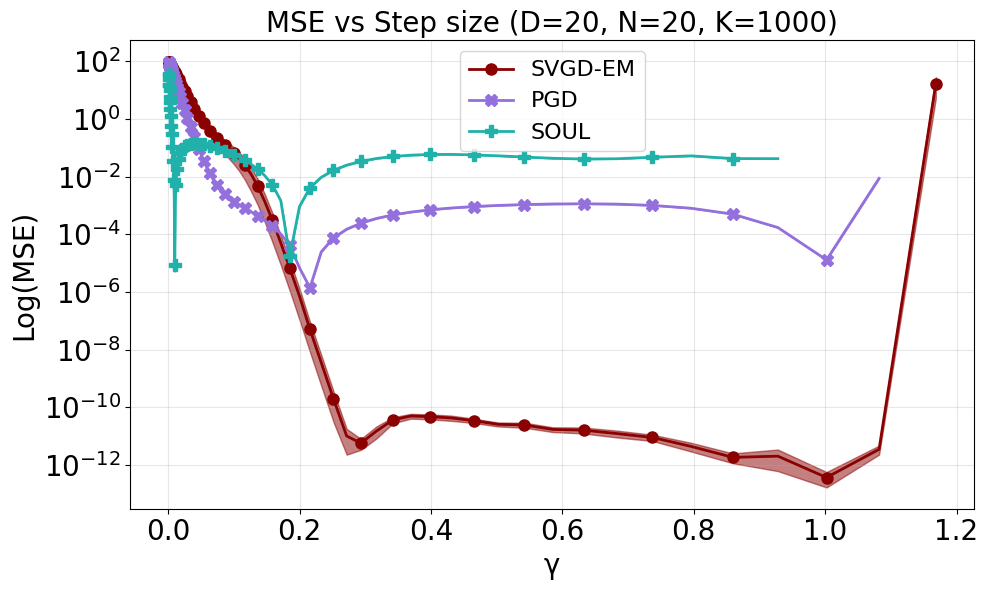

In [20]:
plt.figure(figsize=(10, 6))
for method in ['SVGD-EM', 'PGD', 'SOUL']:
    mse_data = mse_results[method] 
    mean_array = np.array(mse_data['mean'])
    se_array = np.array(mse_data['se'])
    mask = ~np.isnan(mean_array)

    plt.plot(learning_rates[mask], mean_array[mask], label=method, 
            color=method_colors[method], marker=method_markers[method], 
            markersize=8, markevery=2, linewidth=2)
    

    plt.fill_between(
        learning_rates[mask],
        mean_array[mask] - se_array[mask],
        mean_array[mask] + se_array[mask],
        alpha=0.5,
        color=method_colors[method]
    )
        
plt.yscale('log')
#plt.xscale('log')
#plt.xlabel('log(γ)', fontsize=20)
plt.xlabel('γ', fontsize=20)
plt.ylabel('Log(MSE)', fontsize=20)
plt.title(f'MSE vs Step size (D={Dy}, N={N}, K={K})', fontsize=20)
plt.legend(fontsize=16)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"mse_vs_learning_rate_K{K}_log(y_axis).pdf"), dpi=300)
#plt.savefig(os.path.join(save_dir, f"mse_vs_learning_rate_K{K}_loglog.pdf"), dpi=300)
plt.show()



In [9]:
Dy = 20 # Dimensions of data generated
N = 20
K = 1000
shift = 0
dimension_results = {}
Ny=1 # Number of observations
key = jr.PRNGKey(65)
theta = jnp.array([10.0])
key_y, key_latent = jr.split(key)
latent = theta + jr.normal(key_latent, (1, Dy)) * jnp.sqrt(12.0)
y = jr.normal(key_y, (Ny, Dy)) * jnp.sqrt(12.0) + latent
model = HierarchicalModel()
data = Dataset(y=y)

# Verify model mean 10 variance 12
#assert jnp.allclose(model.score_latent(latent, theta, data_mean), ((y_mean + theta - 2.0* latent))/12.0)
#assert jnp.allclose(model.score_theta(latent, theta, data_mean), Dy * (latent.mean() - theta)/12.0)

results = algo_exp(
    model=model,
    data=data,
    y=y,
    num_starts=5,
    N=N,
    Dy=Dy, 
    lr_svgd=0.3,
    lr_soul=0.01,
    lr_pgd=2e-1,
    lr_mpgd=2e-1,
    acceleration_values=[0.3,0.5,0.9],
    gamma_x=0.1,eta_x=20.0,gamma_theta=0.1,eta_theta=20.0,
    run_SOUL=True,
    run_PGD=True,
    run_MPGD=True,  
    run_SVGD_EM=True,
    run_theta_acceleration=False,
    run_particle_acceleration=False,
    run_both_acceleration=True,
    K=1000
)

0.3
0.5
0.9
0.3
0.5
0.9
0.3
0.5
0.9
0.3
0.5
0.9
0.3
0.5
0.9


In [18]:
#np.mean(y)

In [10]:
index=0
dimension_results = results
filtered_results = {}

# M-SVGD-EM
for k, v in results.items():
    if k == 'SVGD-EM' or k==('M-SVGD-EM(0.3)')or k==('M-SVGD-EM(0.5)')or k==('M-SVGD-EM(0.9)') or k == 'PGD' or k == 'MPGD' or k == 'SOUL':
        filtered_results[k] = v

# Individual acceleration methods Appendix supporting figures
# for k, v in results.items():
#     if k == 'SVGD-EM' or k == '$\\theta$A-SVGD-EM(0.8)' or k == 'PA-SVGD-EM(0.8)' or k == 'M-SVGD-EM(0.8)':
#         filtered_results[k] = v

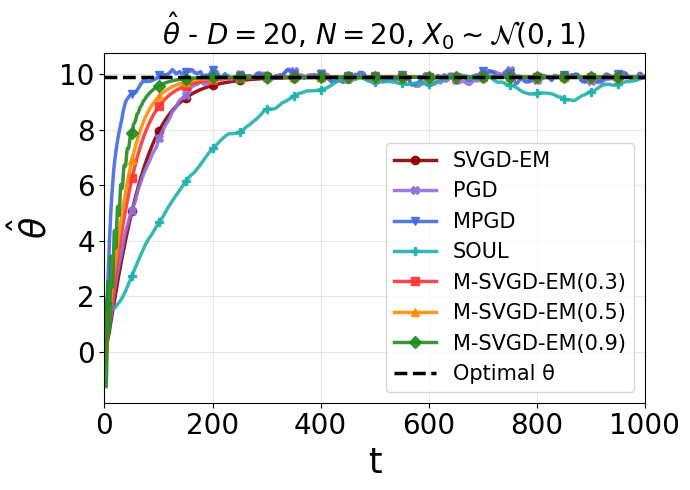

In [11]:
plt.figure(figsize=(7, 5))
y_min, y_max = float('inf'), float('-inf')
for method, data in filtered_results.items():
    traj = data['th'][index]
    y_min = min(y_min, np.min(traj))
    y_max = max(y_max, np.max(traj))

for method, data in filtered_results.items():
    traj = data['th'][index]
    iterations = np.arange(1, len(traj) + 1)
    marker_indices = np.arange(0, len(iterations), 50)
    plt.plot(iterations, traj, label=method, alpha=0.9, 
            color=method_colors.get(method), linewidth=2.5,
            marker=method_markers.get(method), markevery=marker_indices)


plt.axhline(y=np.mean(y), xmin=0, xmax=1, label='Optimal θ', linestyle='--', color='black', linewidth=2.5) # Horizontal line for empirical theta

plt.title(f'$\\hat{{\\theta}}$ - $D={Dy}$, $N={N}$, $X_0 \\sim \\mathcal{{N}}({shift},1)$', fontsize=20)
plt.xlabel('t', fontsize=25)
plt.ylabel(f'$\\hat{{\\theta}}$', fontsize=25)
plt.grid(alpha=0.3)
plt.xlim(0, 1000)
plt.legend(loc='best', fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, f'θ_D{Dy}_N{N}_shift{shift}_optimal_lr.pdf'), 
            dpi=300, bbox_inches='tight')
plt.show()


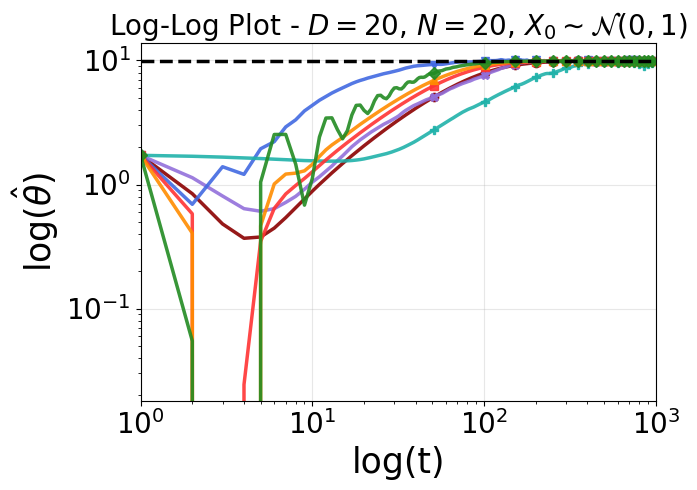

In [12]:
#Log-log plot
plt.figure(figsize=(7, 5))

for method, data in filtered_results.items():
    traj = data['th'][index]
    iterations = np.arange(1, len(traj) + 1)
    marker_indices = np.arange(0, len(iterations), 50)
    plt.loglog(iterations, traj, label=method, alpha=0.9, 
                color=method_colors.get(method), linewidth=2.5,
                marker=method_markers.get(method), markevery=marker_indices)

# Similarly horizontal line for true theta
plt.axhline(y=np.mean(y), xmin=0, xmax=1, label='Optimal θ',
            linestyle='--', color='black', linewidth=2.5)

plt.title(f'Log-Log Plot - $D={Dy}$, $N={N}$, $X_0 \\sim \\mathcal{{N}}({shift},1)$', fontsize=20)
plt.xlabel('log(t)', fontsize=25)
plt.ylabel(f'log($\\hat{{\\theta}}$)', fontsize=25)
plt.grid(alpha=0.3)
plt.xlim(1, K)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, f'loglog_theta_D{Dy}_N{N}_shift{shift}_optimal_lr.pdf'), 
            dpi=300, bbox_inches='tight')
plt.show()



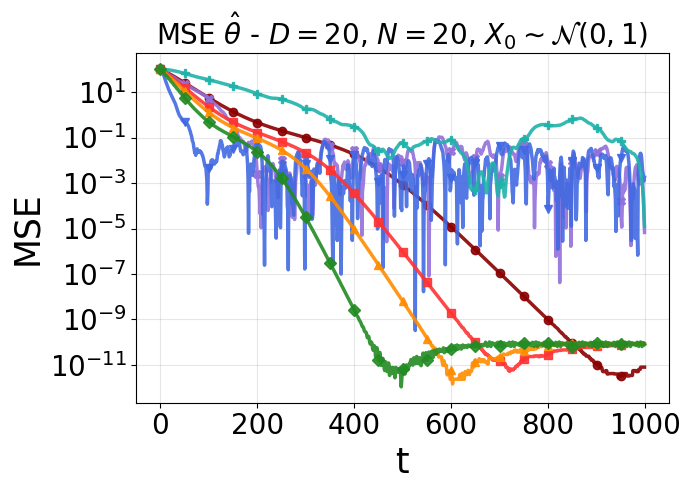

In [13]:
plt.figure(figsize=(7, 5))

for method, data in filtered_results.items():
    # MSE compared to empirical theta
    mse = np.mean([((th - np.mean(y)) ** 2) for th in data['th']], axis=0)
    iterations = np.arange(len(mse))
    marker_indices = np.arange(0, len(iterations), 50)
    plt.plot(iterations, mse, label=method, alpha=0.9, 
            color=method_colors.get(method), linewidth=2.5,
            marker=method_markers.get(method), markevery=marker_indices)

plt.title(f'MSE $\\hat{{\\theta}}$ - $D={Dy}$, $N={N}$, $X_0 \\sim \\mathcal{{N}}({shift},1)$', fontsize=20)
plt.xlabel('t', fontsize=25)
plt.ylabel('MSE', fontsize=25)
plt.grid(alpha=0.3)
plt.yscale('log')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, f'mse_theta_D{Dy}_N{N}_shift{shift}_optimal_lr.pdf'), 
            dpi=300, bbox_inches='tight')
plt.show()



SVGD-EM
M-SVGD-EM(0.3)
M-SVGD-EM(0.5)
M-SVGD-EM(0.9)


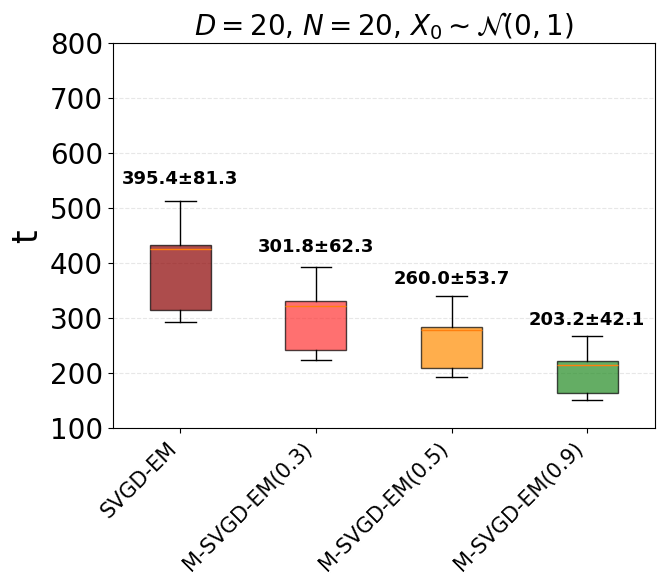

In [14]:
plt.figure(figsize=(7, 5))
boxplot_data = []
labels = []

for method in filtered_results.keys():
    # Skip PGD and SOUL methods
    if method in ['MPGD','PGD', 'SOUL']: # ignore not as steady
        continue
        
    if 'conv_iters' in filtered_results[method]:
        boxplot_data.append(filtered_results[method]['conv_iters'])
        labels.append(method)
    else:
        boxplot_data.append([len(filtered_results[method]['th'][0])] * 5)
        labels.append(method)

boxplot = plt.boxplot(boxplot_data, patch_artist=True, tick_labels=labels)

for i, method in enumerate(labels):
    print(method)
    boxplot['boxes'][i].set(facecolor=method_colors.get(method), alpha=0.7)

for i, data in enumerate(boxplot_data):
    mean_val = np.mean(data)
    std_val = np.std(data)
    plt.text(i+1, np.max(data) + 0.05*np.max(data), 
             f"{mean_val:.1f}±{std_val:.1f}", 
             ha='center', va='bottom', fontsize=13, 
             color='black', fontweight='bold')

plt.title(f'$D={Dy}$, $N={N}$, $X_0 \\sim \\mathcal{{N}}({shift},1)$', fontsize=20)
plt.ylabel('t', fontsize=25)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right', fontsize=15)
plt.yticks(fontsize=20)
plt.ylim(100,800) # Adjust as needed depending on kernel,steps etc...
plt.savefig(os.path.join(save_dir, f'convergence_boxplot_D{Dy}_N{N}_shift{shift}_optimal_lr.pdf'), 
            dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
end=time.time()
print(f"Time taken whole notebook: {end-start_time:.4f} seconds")
#443.3417 seconds running all the code trial 1 
#495.7056 seconds running all the code trial 2 
#504.2620 seconds running all the code trial 3 
#486.1150 seconds running all the code trial 4 
#556.0438 seconds running all the code trial 5 
#497.0936 seconds average